In [5]:
#First row of cvs is title, skipped when importing
all_events<- read.csv("climate-attitude-capstone-project/data/disaster-event-data/events-name-US-2008-2024.csv",skip=2)
head(all_events)

,Name,Disaster,Begin.Date,End.Date,CPI.Adjusted.Cost,Unadjusted.Cost,Deaths
,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<int>
1,"Western, Central and Northeast Severe Weather (January 2008)",Severe Storm,20080104,20080109,1473.0,982.0,12
2,Southeast Tornadoes and Severe Weather (February 2008),Severe Storm,20080205,20080206,1805.3,1211.6,57
3,Southeast Tornadoes (March 2008),Severe Storm,20080314,20080315,1673.9,1131.0,5
4,Southern Severe Weather (April 2008),Severe Storm,20080409,20080411,1528.3,1039.6,2
5,Midwest Tornadoes and Severe Weather (May 2008),Severe Storm,20080522,20080527,4423.1,3029.5,13
6,Midwest/Mid-Atlantic Severe Weather (June 2008),Severe Storm,20080606,20080612,2355.7,1635.9,18


In [6]:
library(dplyr)
library(tidyverse)
        
glimpse(all_events)


Attaching package: ‘dplyr’




The following objects are masked from ‘package:stats’:

    filter, lag




The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ lubridate 1.9.4     ✔ tibble    3.3.0
✔ purrr     1.1.0     ✔ tidyr     1.3.1
✔ readr     2.1.5     


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


Rows: 267
Columns: 7
$ Name              <chr> "Western, Central and Northeast Severe Weather (Janu…
$ Disaster          <chr> "Severe Storm", "Severe Storm", "Severe Storm", "Sev…
$ Begin.Date        <int> 20080104, 20080205, 20080314, 20080409, 20080522, 20…
$ End.Date          <int> 20080109, 20080206, 20080315, 20080411, 20080527, 20…
$ CPI.Adjusted.Cost <dbl> 1473.0, 1805.3, 1673.9, 1528.3, 4423.1, 2355.7, 1493…
$ Unadjusted.Cost   <dbl> 982.0, 1211.6, 1131.0, 1039.6, 3029.5, 1635.9, 9958.…
$ Deaths            <int> 12, 57, 5, 2, 13, 18, 24, 3, 53, 112, 16, 0, 10, 0, …


In [7]:
#format date columns 
# display
all_events$date<- as.Date(as.character(all_events$Begin.Date),format = "%Y%m%d")


# display

head(all_events)

,Name,Disaster,Begin.Date,End.Date,CPI.Adjusted.Cost,Unadjusted.Cost,Deaths,date
,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<int>,<date>
1,"Western, Central and Northeast Severe Weather (January 2008)",Severe Storm,20080104,20080109,1473.0,982.0,12,2008-01-04
2,Southeast Tornadoes and Severe Weather (February 2008),Severe Storm,20080205,20080206,1805.3,1211.6,57,2008-02-05
3,Southeast Tornadoes (March 2008),Severe Storm,20080314,20080315,1673.9,1131.0,5,2008-03-14
4,Southern Severe Weather (April 2008),Severe Storm,20080409,20080411,1528.3,1039.6,2,2008-04-09
5,Midwest Tornadoes and Severe Weather (May 2008),Severe Storm,20080522,20080527,4423.1,3029.5,13,2008-05-22
6,Midwest/Mid-Atlantic Severe Weather (June 2008),Severe Storm,20080606,20080612,2355.7,1635.9,18,2008-06-06


In [8]:
#clean name of storm column to remove month and year
all_events$Name <- gsub(" \\(.*","", all_events$Name)

head(all_events)


,Name,Disaster,Begin.Date,End.Date,CPI.Adjusted.Cost,Unadjusted.Cost,Deaths,date
,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<int>,<date>
1,"Western, Central and Northeast Severe Weather",Severe Storm,20080104,20080109,1473.0,982.0,12,2008-01-04
2,Southeast Tornadoes and Severe Weather,Severe Storm,20080205,20080206,1805.3,1211.6,57,2008-02-05
3,Southeast Tornadoes,Severe Storm,20080314,20080315,1673.9,1131.0,5,2008-03-14
4,Southern Severe Weather,Severe Storm,20080409,20080411,1528.3,1039.6,2,2008-04-09
5,Midwest Tornadoes and Severe Weather,Severe Storm,20080522,20080527,4423.1,3029.5,13,2008-05-22
6,Midwest/Mid-Atlantic Severe Weather,Severe Storm,20080606,20080612,2355.7,1635.9,18,2008-06-06


In [9]:
#filter dataset for only columns wanted in analysis
#using name, disaser type, CPI adjusted cost in millions of dollars, number of deaths, and data

all_events_clean <- all_events %>%
    select(Name, Disaster, CPI.Adjusted.Cost, Deaths, date)

all_events_clean


Name,Disaster,CPI.Adjusted.Cost,Deaths,date
<chr>,<chr>,<dbl>,<int>,<date>
"Western, Central and Northeast Severe Weather",Severe Storm,1473.0,12,2008-01-04
Southeast Tornadoes and Severe Weather,Severe Storm,1805.3,57,2008-02-05
Southeast Tornadoes,Severe Storm,1673.9,5,2008-03-14
Southern Severe Weather,Severe Storm,1528.3,2,2008-04-09
Midwest Tornadoes and Severe Weather,Severe Storm,4423.1,13,2008-05-22
Midwest/Mid-Atlantic Severe Weather,Severe Storm,2355.7,18,2008-06-06
Midwest Flooding,Flooding,14937.8,24,2008-04-01
Hurricane Dolly,Tropical Cyclone,1812.2,3,2008-07-23
Hurricane Gustav,Tropical Cyclone,8635.7,53,2008-08-31


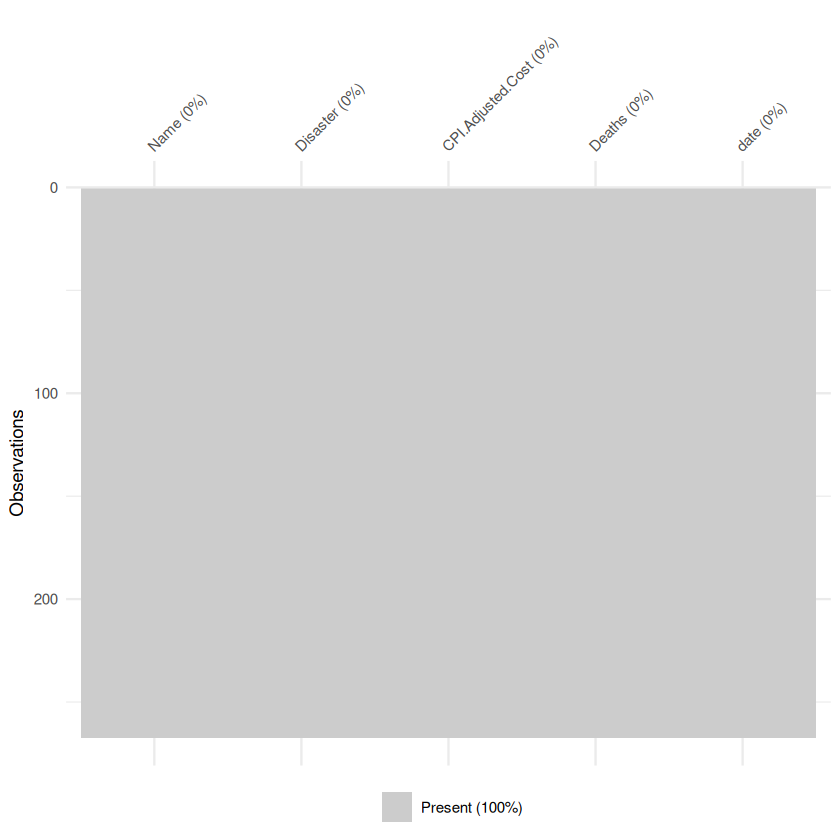

In [13]:
#check for missing data
#install.packages("naniar")
library(naniar)

# visualize missingness
vis_miss(all_events_clean)

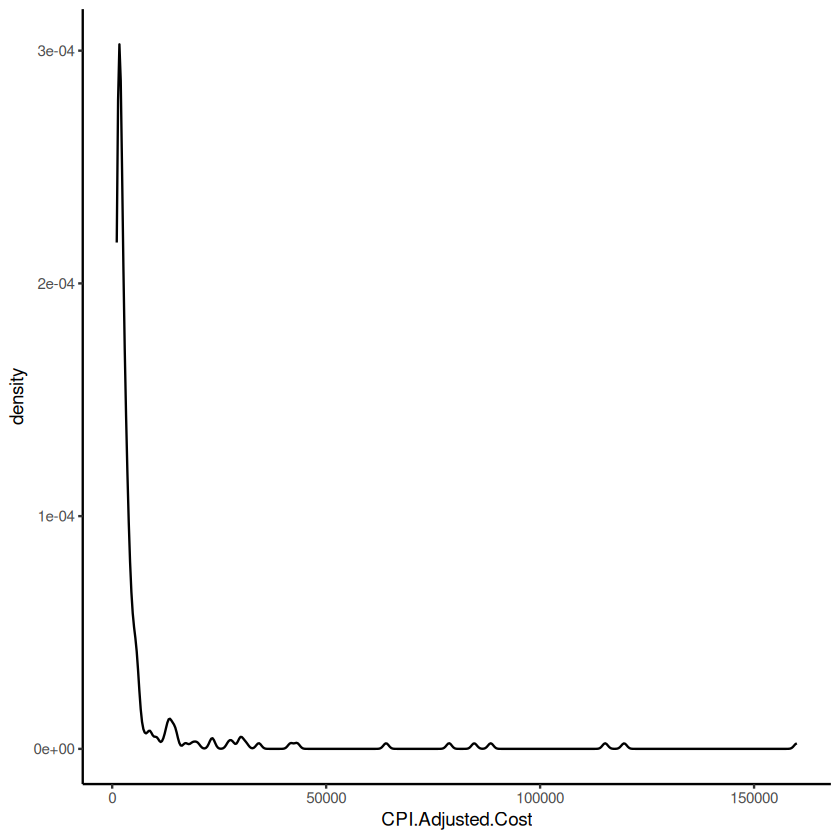

In [15]:
#all clean! hooray! let's look at the data a little more. is there any value in a density plot?

all_events_clean %>% 
  ggplot(aes(x=CPI.Adjusted.Cost)) +
  geom_density() +
  theme_classic()

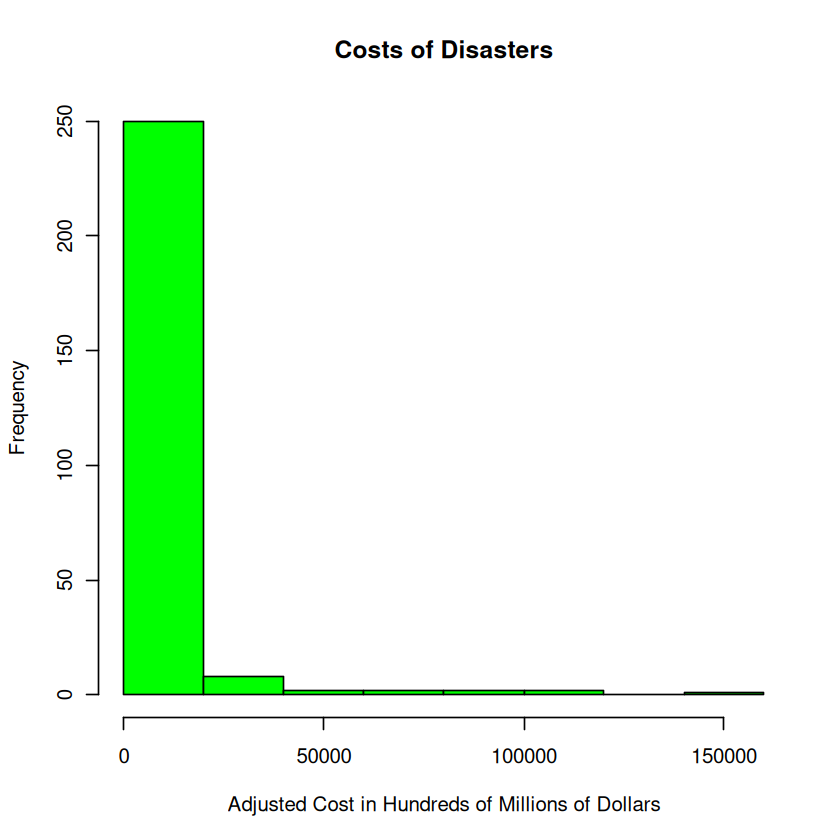

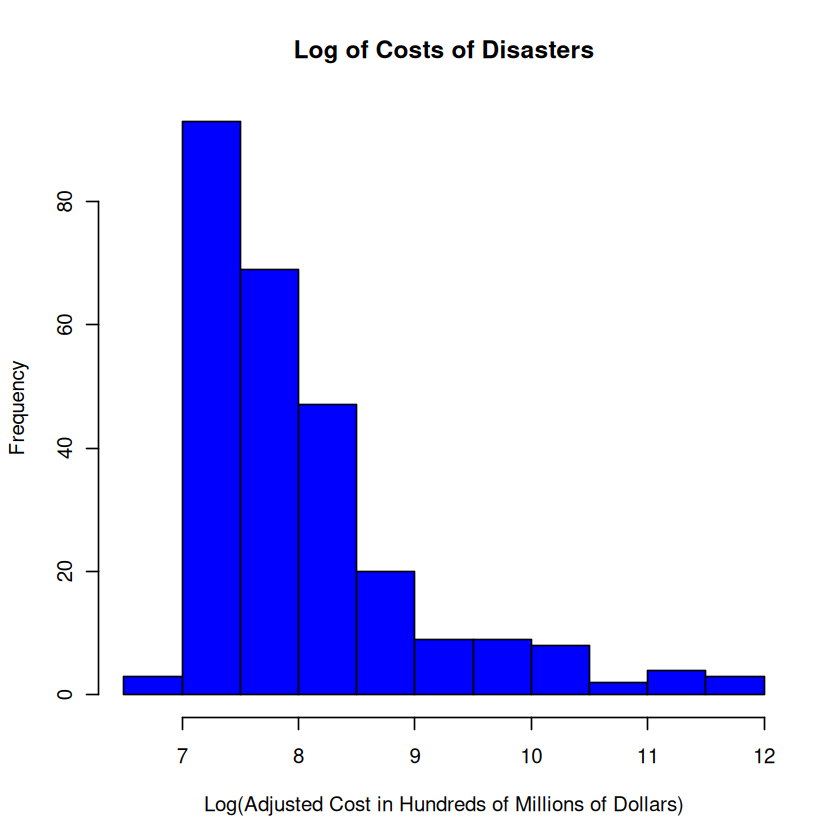

In [27]:
#not really. what about some basic histograms?

hist(all_events_clean$CPI.Adjusted.Cost, col = "Green",
     main = "Costs of Disasters",
     xlab = "Adjusted Cost in Hundreds of Millions of Dollars")
hist(log(all_events_clean$CPI.Adjusted.Cost), col = "Blue",
     main = "Log of Costs of Disasters",
     xlab = "Log(Adjusted Cost in Hundreds of Millions of Dollars)")

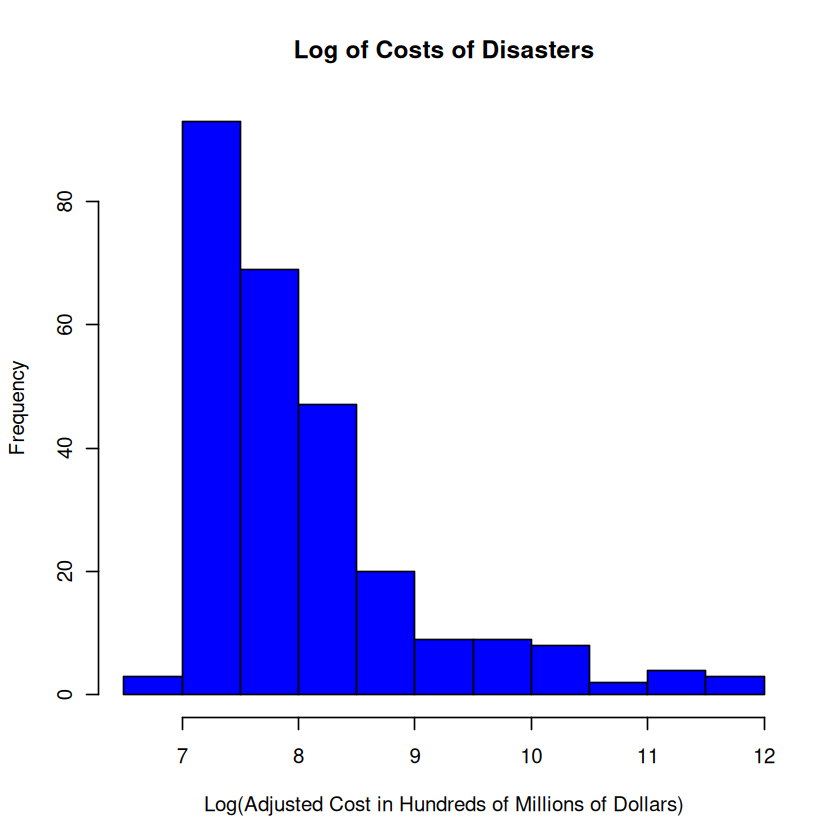

In [18]:
#so  can see that most of the disasters cost less than $50B. does a log scale show anything different?
hist(log(all_events_clean$CPI.Adjusted.Cost), col = "Blue",
     main = "Log of Costs of Disasters",
     xlab = "Log(Adjusted Cost in Hundreds of Millions of Dollars)")

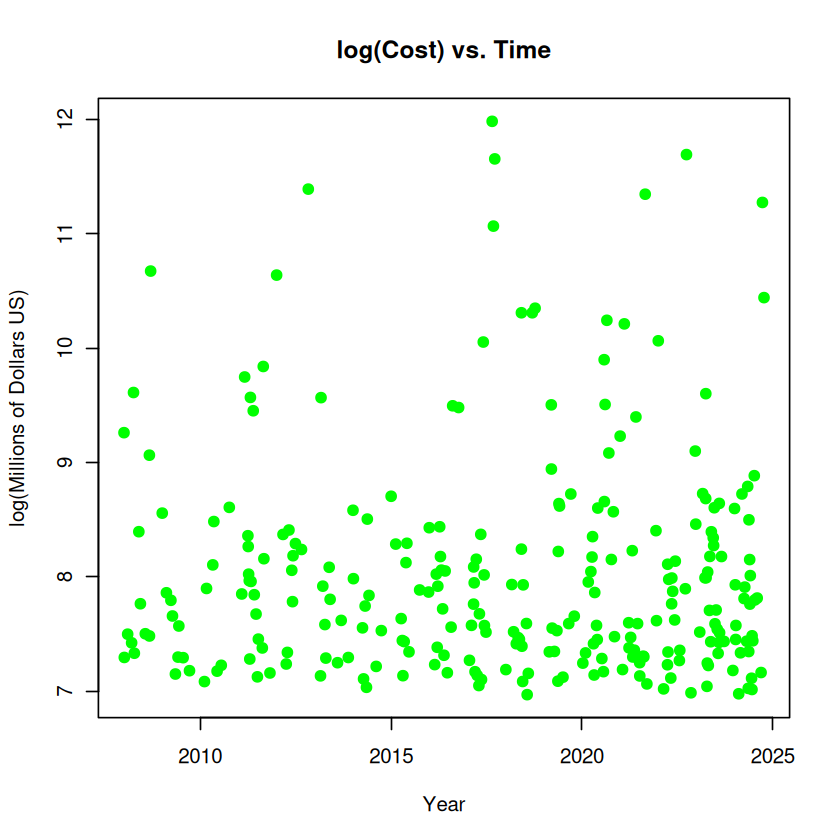

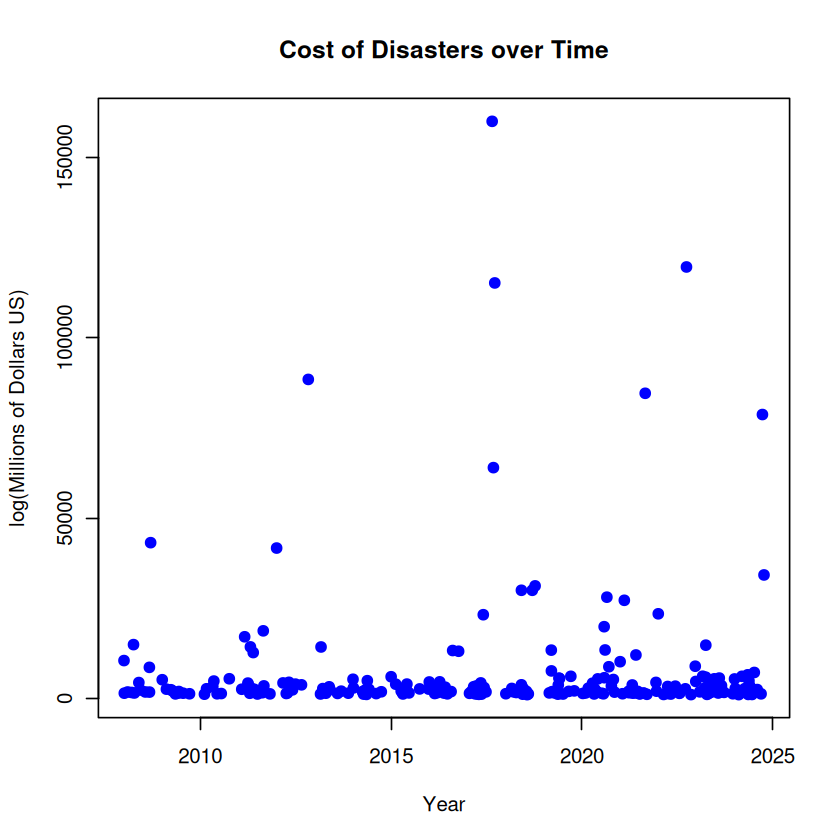

In [26]:
plot(log(all_events_clean$CPI.Adjusted.Cost) ~ all_events_clean$date,
     col = "green",
     pch = 19,
     main = "log(Cost) vs. Time",
     xlab = "Year",
     ylab = "log(Millions of Dollars US)")

plot(all_events_clean$CPI.Adjusted.Cost ~ all_events_clean$date,
     col = "blue",
     pch = 19,
     main = "Cost of Disasters over Time",
     xlab = "Year",
     ylab = "log(Millions of Dollars US)")

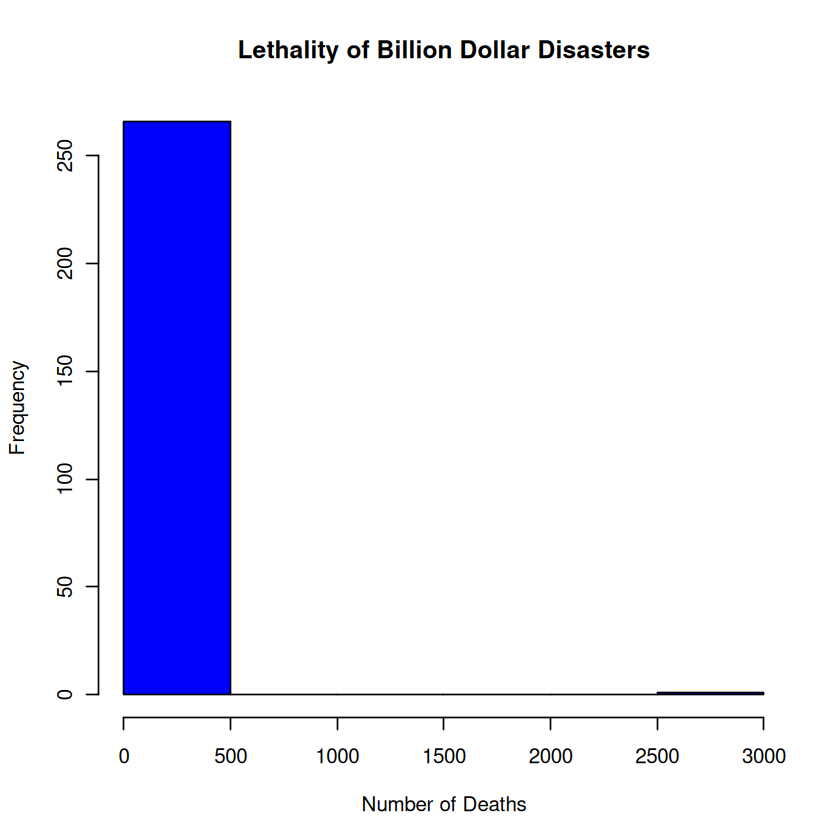

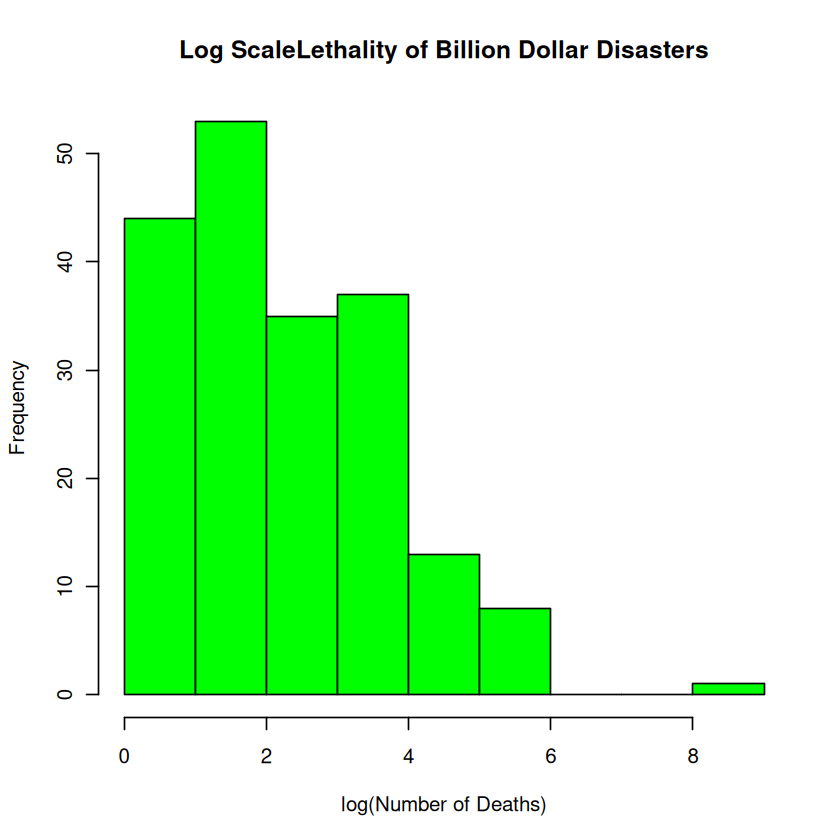

In [23]:
hist(all_events_clean$Deaths, col = "blue",
     main = "Lethality of Billion Dollar Disasters",
     xlab = "Number of Deaths")

hist(log(all_events_clean$Deaths), col = "green",
     main = "Log ScaleLethality of Billion Dollar Disasters",
     xlab = "log(Number of Deaths)")

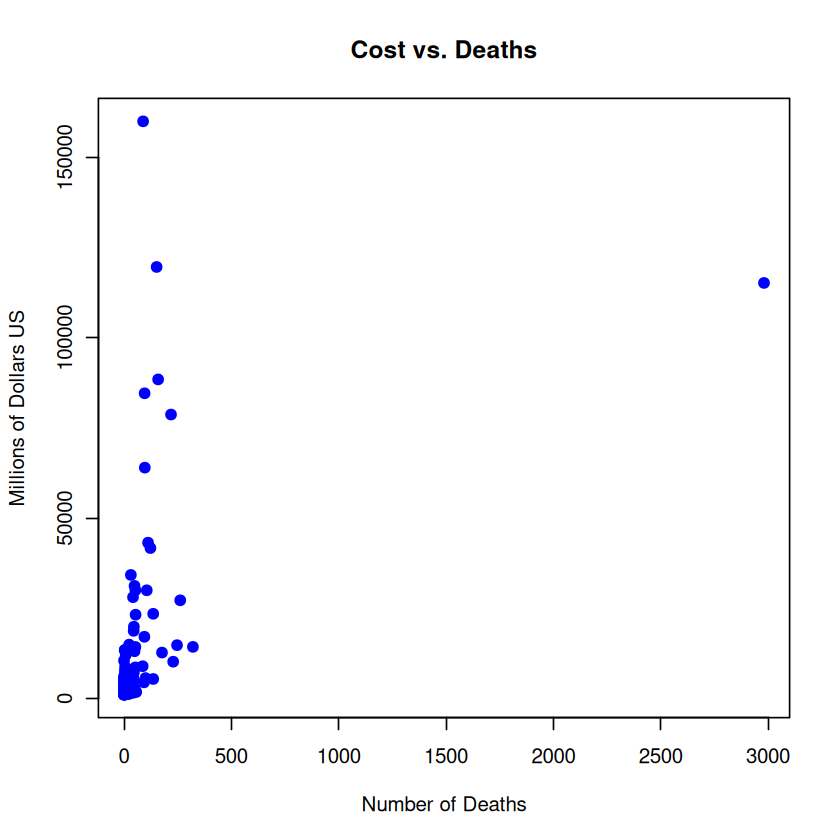

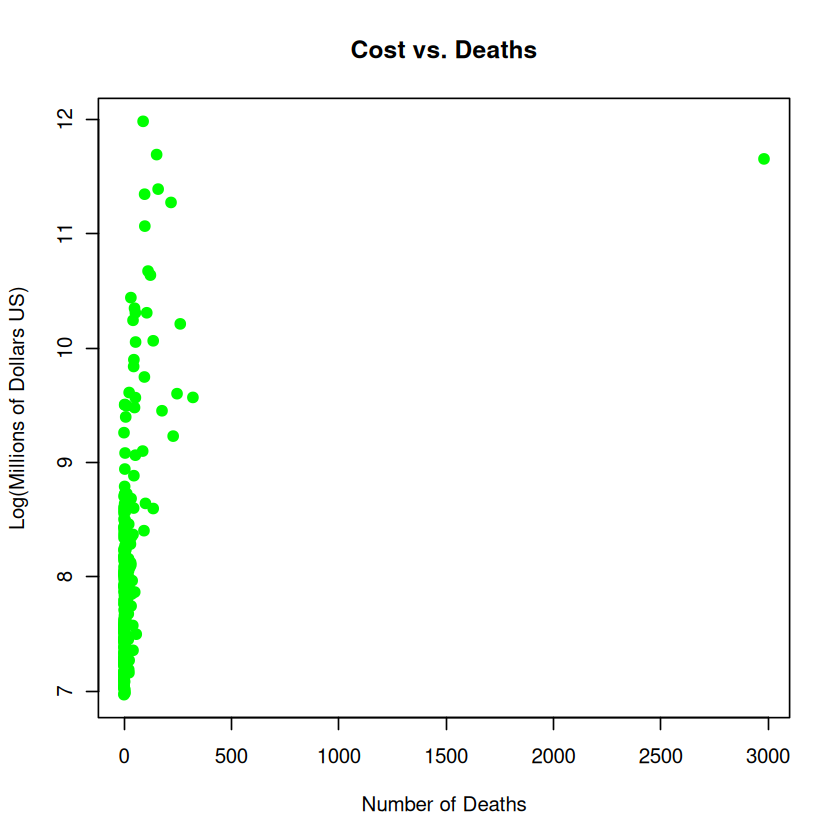

In [25]:
plot(all_events_clean$CPI.Adjusted.Cost ~ all_events_clean$Death,
     col = "blue",
     pch = 19,
     main = "Cost vs. Deaths",
     xlab = "Number of Deaths",
     ylab = "Millions of Dollars US")

plot(log(all_events_clean$CPI.Adjusted.Cost) ~ all_events_clean$Death,
     col = "green",
     pch = 19,
     main = "Cost vs. Deaths",
     xlab = "Number of Deaths",
     ylab = "Log(Millions of Dollars US)")

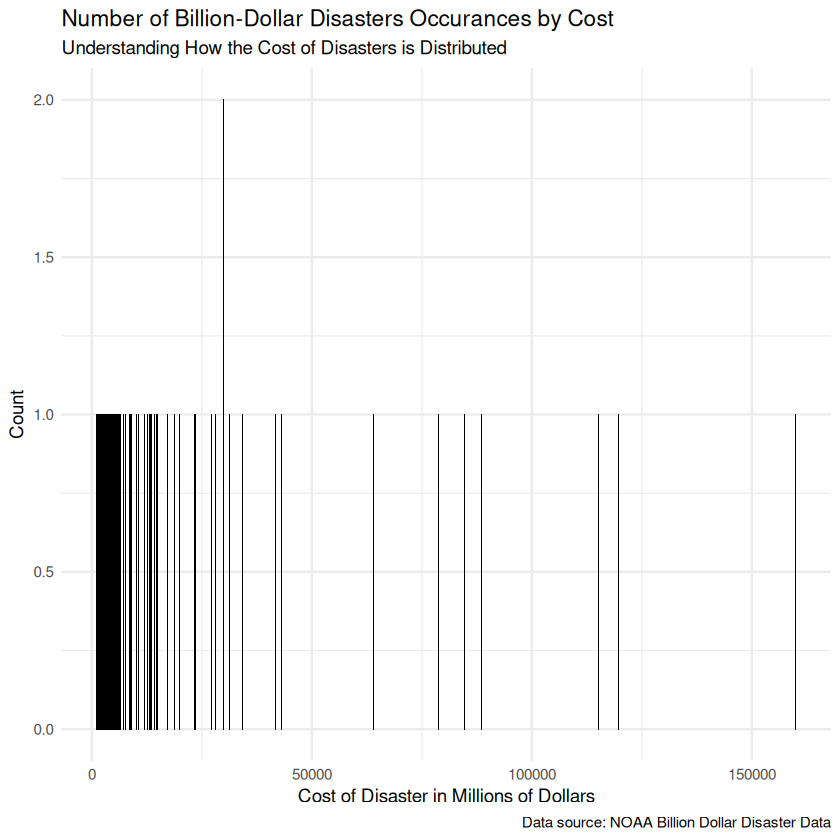

In [35]:
basic_bar <- ggplot(all_events_clean, aes(x = CPI.Adjusted.Cost)) +
  geom_bar(fill = "black") +
  labs(
    title = "Number of Billion-Dollar Disasters Occurances by Cost",
    subtitle = "Understanding How the Cost of Disasters is Distributed",  # Optional
    x = "Cost of Disaster in Millions of Dollars",
    y = "Count",
    caption = "Data source: NOAA Billion Dollar Disaster Data"  # Optional
  ) +
  theme_minimal()
print(basic_bar)

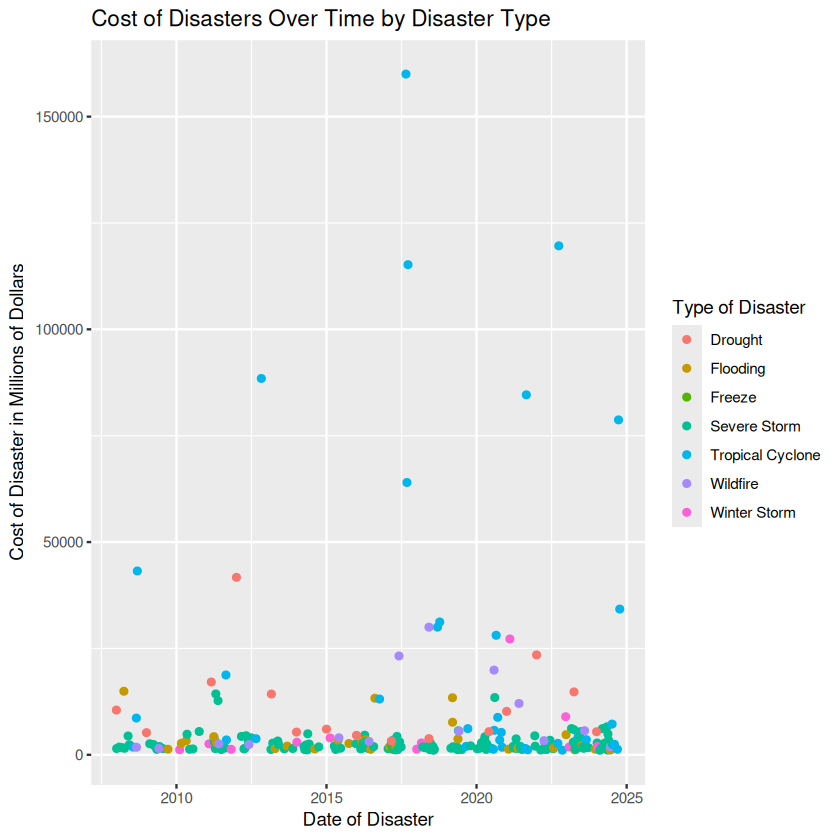

In [10]:
library(ggplot2)

ggplot(all_events_clean, aes(x = date, y = CPI.Adjusted.Cost, color = Disaster)) +
    geom_point() +
    labs(title = "Cost of Disasters Over Time by Disaster Type",
         x = "Date of Disaster",
         y = "Cost of Disaster in Millions of Dollars",
         color = "Type of Disaster")